In [1]:
import spectfbcalc_lib as sfc
from matplotlib import pyplot as plt
import xarray as xr
import yaml
import glob
from climtools import climtools_lib as ctl
import numpy as np

No DISPLAY variable set. Switching to agg backend


In [16]:
from importlib import reload
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [120]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=4,
    memory="64GB",
    processes=4,
    walltime="00:10:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitfabi",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=4)  # This submits 4 SLURM jobs

# Connect client
client = Client(cluster)

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36405 instead
  warnings.warn(


In [35]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.100.192.102:32943/status,
Dashboard: http://10.100.192.102:32943/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.100.192.102:43735,Workers: 0
Dashboard: http://10.100.192.102:32943/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [6]:
import warnings
warnings.filterwarnings('once')

In [4]:
config_file = 'config_zelinka.yml'
control1, experiment1, kernel1 = sfc.preprocess_data(config_file, ker = 'HUANG', wv_method_spectral='hybrid')

Time range for climatology: {'start': '2540-01-16 12:00:00', 'end': '2560-12-30 12:00:00'}
Time range for experiment: all
Loading kernel: HUANG



 -------> Loading control
PI already remapped
Computing albedo from rsus and rsds
Applying log to hus
Creating Net TOA variables
-> rsut loaded
-> rlut loaded
-> ts loaded
-> rsutcs loaded
-> alb loaded
-> rsdt loaded
-> hus_log loaded
-> tas loaded
-> rlutcs loaded
-> ta loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Loading experiment
4x already remapped
Computing albedo from rsus and rsds
Applying log to hus
Creating Net TOA variables
-> rsut loaded
-> rlut loaded
-> ts loaded
-> rsutcs loaded
-> alb loaded
-> rsdt loaded
-> hus_log loaded
-> tas loaded
-> rlutcs loaded
-> ta loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Computing climatology and anomalies
Frozen({'time': (120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 60), 'lat': (73,), 'lon': (144,), 'plev': (24,)}) Frozen({})

 -------> Recomputing atm dp with surface pressure

Loading surface pressure data...


/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:636: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  surf_pressure = xr.open_mfdataset(ps_files, combine='by_coords', decode_times=time_coder, preprocess=preproc)


Surface pressure regular grid detected. Using standard regrid...
Regridding...
Regridding completed in 0:00:04.004873
Computing climatology on remapped surface pressure...
Converting surf pres from Pa to hPa
Surface pressure successfully loaded, remapped and averaged.

 ----------> Preprocessing complete for ece3_abrupt <------------



/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:172: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  wid_mask = xr.DataArray(wid_mask, dims = k.dims[1:], coords = k.drop('month').coords)


In [32]:
sorted(kernel1.kernel[('clr', 't')].plev.values)[::-1]

[np.float32(1000.0),
 np.float32(975.0),
 np.float32(950.0),
 np.float32(925.0),
 np.float32(900.0),
 np.float32(875.0),
 np.float32(850.0),
 np.float32(825.0),
 np.float32(800.0),
 np.float32(775.0),
 np.float32(725.0),
 np.float32(625.0),
 np.float32(525.0),
 np.float32(425.0),
 np.float32(325.0),
 np.float32(237.5),
 np.float32(187.5),
 np.float32(137.5),
 np.float32(85.0),
 np.float32(40.0),
 np.float32(15.0),
 np.float32(6.0),
 np.float32(2.5),
 np.float32(1.0)]

In [5]:
config_file = 'config_zelinka.yml'
control, experiment, kernel = sfc.preprocess_data(config_file, ker = 'SPECTRAL', wv_method_spectral='hybrid')

Time range for climatology: {'start': '2540-01-16 12:00:00', 'end': '2560-12-30 12:00:00'}
Time range for experiment: all
Loading kernel: SPECTRAL



 -------> Loading control
PI already remapped
Computing albedo from rsus and rsds
Converting hus to wv vmr
Creating Net TOA variables
-> rsut loaded
-> wv_vmr loaded
-> rlut loaded
-> ts loaded
-> rsutcs loaded
-> alb loaded
-> wv_vmr_log loaded
-> rsdt loaded
-> tas loaded
-> rlutcs loaded
-> ta loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Loading experiment
4x already remapped
Computing albedo from rsus and rsds
Converting hus to wv vmr
Creating Net TOA variables
-> rsut loaded
-> wv_vmr loaded
-> rlut loaded
-> ts loaded
-> rsutcs loaded
-> alb loaded
-> wv_vmr_log loaded
-> rsdt loaded
-> tas loaded
-> rlutcs loaded
-> ta loaded
check vertical dimension
Converting vertical coordinates from Pa to hPa

 -------> Computing climatology and anomalies
Frozen({'time': (120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 60), 'lat': (30, 30, 30), 'lon': (36, 36, 36, 36), 'plev': (18,)}) Frozen({})

 ----------> Prepr

In [5]:
control.ds

<xarray.Dataset> Size: 836MB
Dimensions:     (time: 252, lon: 144, lat: 90, plev: 18)
Coordinates:
  * time        (time) object 2kB 2540-01-16 12:00:00 ... 2560-12-16 12:00:00
  * lon         (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
  * lat         (lat) int64 720B -89 -87 -85 -83 -81 -79 ... 79 81 83 85 87 89
  * plev        (plev) float64 144B 1.0 10.0 20.0 30.0 ... 850.0 925.0 1e+03
    height      float64 8B ...
Data variables: (12/13)
    rlut        (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    rlutcs      (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    rsdt        (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    rsut        (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    rsutcs      (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    ta          (time, plev, lat, lon) float32 235MB dask.array<chunksize=(120, 18, 30, 36), meta=np.ndarray>
    ...          ...
    ts          (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    alb         (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    wv_vmr      (time, plev, lat, lon) float32 235MB dask.array<chunksize=(120, 18, 30, 36), meta=np.ndarray>
    wv_vmr_log  (time, plev, lat, lon) float32 235MB dask.array<chunksize=(120, 18, 30, 36), meta=np.ndarray>
    net_toa     (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>
    net_toa_cs  (time, lat, lon) float32 13MB dask.array<chunksize=(120, 30, 36), meta=np.ndarray>

In [9]:
kernel.kernel[('clr', 't')].plev

<xarray.DataArray 'plev' (plev: 18)> Size: 144B
array([   1.,   10.,   20.,   30.,   50.,   70.,  100.,  150.,  200.,  250.,
        300.,  400.,  500.,  600.,  700.,  850.,  925., 1000.])
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03

In [13]:
experiment.ds_anom['ta'].plev

<xarray.DataArray 'plev' (plev: 18)> Size: 144B
array([   1.,   10.,   20.,   30.,   50.,   70.,  100.,  150.,  200.,  250.,
        300.,  400.,  500.,  600.,  700.,  850.,  925., 1000.])
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03

In [46]:
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [123]:
mask = sfc.mask_strato(experiment.ds_anom['ta'])

In [57]:
mask

<xarray.DataArray 'plev' (plev: 18, time: 1980, lat: 90, lon: 144)> Size: 4GB
dask.array<rechunk-merge, shape=(18, 1980, 90, 144), dtype=int64, chunksize=(18, 120, 30, 36), chunktype=numpy.ndarray>
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Attributes:
    regrid_method:  bilinear

In [31]:
mask.name = 'lapse'

In [122]:
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [124]:
mask = mask.mean('lon')
mask_ini = mask.isel(time = slice(0, 120)).mean('time')
mask_fin = mask.isel(time = slice(-120, None)).mean('time')

In [125]:
mask_ini.load()
mask_fin.load()

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 29.60 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'plev' (plev: 18, lat: 90)> Size: 13kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(18, 90))
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
Attributes:
    regrid_method:  bilinear

In [126]:
%matplotlib inline

In [127]:
mask_ini

<xarray.DataArray 'plev' (plev: 18, lat: 90)> Size: 13kB
array([[0.00474537, 0.0056713 , 0.00162037, ..., 0.01649306, 0.01145833,
        0.00787037],
       [0.00474537, 0.0056713 , 0.00162037, ..., 0.01649306, 0.01145833,
        0.00787037],
       [0.00474537, 0.0056713 , 0.00162037, ..., 0.01649306, 0.01145833,
        0.00787037],
       ...,
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(18, 90))
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
Attributes:
    regrid_method:  bilinear

In [128]:
mask_ini.plev

<xarray.DataArray 'plev' (plev: 18)> Size: 144B
array([   1.,   10.,   20.,   30.,   50.,   70.,  100.,  150.,  200.,  250.,
        300.,  400.,  500.,  600.,  700.,  850.,  925., 1000.])
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03

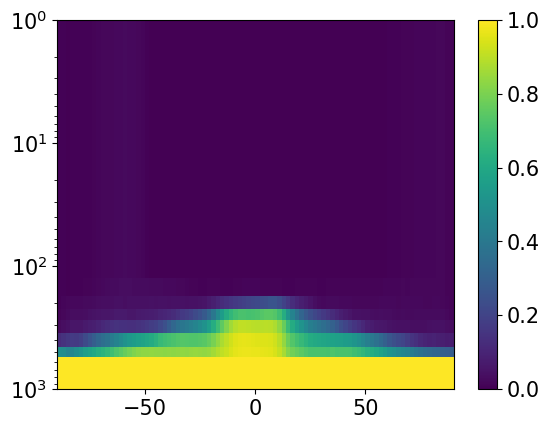

In [129]:
fig, ax = plt.subplots()
plt.pcolormesh(mask_ini.lat, mask_ini.plev, mask_ini.values)#, vmin = 0, vmax = 1)
#ax.set_yscale('log')
ax.set_ylim(1000., 1.)
ax.set_yscale('log')
plt.colorbar()

In [109]:
mask

<xarray.DataArray 'plev' (plev: 18, time: 1980, lat: 90)> Size: 26MB
dask.array<mean_agg-aggregate, shape=(18, 1980, 90), dtype=float64, chunksize=(18, 120, 30), chunktype=numpy.ndarray>
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
Attributes:
    regrid_method:  bilinear

In [111]:
xr.__version__

'2026.2.0'

In [114]:
mask

<xarray.DataArray 'plev' (plev: 18, time: 1980, lat: 90)> Size: 26MB
dask.array<mean_agg-aggregate, shape=(18, 1980, 90), dtype=float64, chunksize=(18, 120, 30), chunktype=numpy.ndarray>
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
Attributes:
    regrid_method:  bilinear

In [ ]:
for lev in mask.plev:
    ones_above = mask.sel(plev = slice(lev, )).astype(int).cumsum('plev', skipna=False)
    ones_above = ones_above.flip('plev')

    da_filtered = xr.where((da == 0) & (ones_above > 0), 1, da)


Signature:
mask.transpose(
    *dim: 'Hashable',
    transpose_coords: 'bool' = True,
    missing_dims: 'ErrorOptionsWithWarn' = 'raise',
) -> 'Self'
Docstring:
Return a new DataArray object with transposed dimensions.

Parameters
----------
*dim : Hashable, optional
    By default, reverse the dimensions. Otherwise, reorder the
    dimensions to this order.
transpose_coords : bool, default: True
    If True, also transpose the coordinates of this DataArray.
missing_dims : {"raise", "warn", "ignore"}, default: "raise"
    What to do if dimensions that should be selected from are not present in the
    DataArray:
    - "raise": raise an exception
    - "warn": raise a warning, and ignore the missing dimensions
    - "ignore": ignore the missing dimensions

Returns
-------
transposed : DataArray
    The returned DataArray's array is transposed.

Notes
-----
This operation returns a view of this array's data. It is
lazy for dask-backed DataArrays but not for numpy-backed DataArrays
-- the

In [110]:
mask.flip('plev')

AttributeError: 'DataArray' object has no attribute 'flip'

In [ ]:
ones_above = (da == 1).astype(int).cumsum('plev', skipna=False)
ones_above = ones_above.sel(plev=da.plev.values[::-1]).cumsum('plev', skipna=False).isel(plev=slice(None, None, -1))

# Actually simpler: reverse, cumsum, reverse
da_flipped = da.isel(plev=slice(None, None, -1))
ones_above = (da_flipped == 1).astype(int).cumsum('plev', skipna=False)
ones_above = ones_above.isel(plev=slice(None, None, -1))

# Replace lonely 0s: where da==0 AND there's at least one 1 above (lower pressure), set to 1
da_filtered = xr.where((da == 0) & (ones_above > 0), 1, da)

In [101]:
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [16]:
experiment.ds_anom['ta'].plev.values

array([   1.,   10.,   20.,   30.,   50.,   70.,  100.,  150.,  200.,
        250.,  300.,  400.,  500.,  600.,  700.,  850.,  925., 1000.])

In [102]:
mask, lapse, cond = sfc.mask_strato(experiment.ds_anom['ta'], debug = True)

In [103]:
mask_ok, lapse_ok, cond_ok = sfc.mask_strato(experiment1.ds_anom['ta'], debug = True)

In [104]:
lapse = lapse.mean('lon')
lapse_ini = lapse.isel(time = slice(0, 120)).mean('time')
lapse_fin = lapse.isel(time = slice(-120, None)).mean('time')

cond = cond.mean('lon')
cond_ini = cond.isel(time = slice(0, 120)).mean('time')
cond_fin = cond.isel(time = slice(-120, None)).mean('time')

In [105]:
lapse_ok = lapse_ok.mean('lon')
lapse_ok_ini = lapse_ok.isel(time = slice(0, 120)).mean('time')
lapse_ok_fin = lapse_ok.isel(time = slice(-120, None)).mean('time')

cond_ok = cond_ok.mean('lon')
cond_ok_ini = cond_ok.isel(time = slice(0, 120)).mean('time')
cond_ok_fin = cond_ok.isel(time = slice(-120, None)).mean('time')

In [93]:
lapse_ini.load()

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 17.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'lapse' (plev_k: 17, lat: 90)> Size: 12kB
array([[  5.72193005,  14.57948096,  20.8257311 , ..., 117.46780776,
         79.12419258, 440.10169067],
       [  4.36807907,   6.18293481,  -4.67448154, ...,  27.06248085,
         28.20211343,  53.65222831],
       [ 27.7767913 , 338.05615026,  -6.6038243 , ..., -81.15370819,
         11.03380831,  21.11582821],
       ...,
       [-19.11062275, -23.56750798, -24.50340762, ..., -20.27685953,
        -19.80704402, -18.67878832],
       [-13.01091315, -11.60097846, -11.7836024 , ..., -16.02982838,
         -2.12635309, -14.36729767],
       [ -7.05767778,  -7.09412492,  -7.16910597, ..., -10.98293945,
        -11.11885073, -11.16341715]], shape=(17, 90))
Coordinates:
  * plev_k   (plev_k) float64 136B 7.111 6.948 6.679 6.354 ... 2.497 2.141 1.465
    plev     (plev_k) float64 136B 962.0 886.9 772.4 648.6 ... 24.64 14.39 3.809
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
Attributes:
    regrid_method:  bilinear

In [100]:
ta_ok.sel(plev = ta_ok.plev.values[::-1]).plev

<xarray.DataArray 'plev' (plev: 18)> Size: 144B
array([1000.,  925.,  850.,  700.,  600.,  500.,  400.,  300.,  250.,  200.,
        150.,  100.,   70.,   50.,   30.,   20.,   10.,    1.])
Coordinates:
  * plev     (plev) float64 144B 1e+03 925.0 850.0 700.0 ... 30.0 20.0 10.0 1.0
    height   float64 8B 2.0

In [94]:
cond_ini.load()

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 28.01 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'plev' (plev: 18, lat: 90)> Size: 13kB
array([[0.55914352, 0.56649306, 0.58275463, ..., 0.57905093, 0.57673611,
        0.57725694],
       [0.98333333, 0.98107639, 0.98125   , ..., 0.8515625 , 0.8552662 ,
        0.85515046],
       [0.98987269, 0.98917824, 0.98842593, ..., 0.86828704, 0.87447917,
        0.8712963 ],
       ...,
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(18, 90))
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
Attributes:
    regrid_method:  bilinear

In [95]:
lapse_ok_ini.load()

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 12.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'lapse' (plev_k: 23, lat: 73)> Size: 7kB
array([[  94.70196  ,   39.270874 ,   57.475334 , ...,   11.475698 ,
           6.1292114,    6.6191053],
       [  34.387856 ,   50.410683 , 1045.9725   , ...,   20.17464  ,
         -17.008602 ,    6.57189  ],
       [  47.922207 , -189.06479  ,  116.65825  , ...,    9.424512 ,
           4.944575 ,    6.5340924],
       ...,
       [  37.18124  ,  -39.03159  ,    8.571184 , ...,  -12.013492 ,
         -11.204973 ,  -11.0720005],
       [  22.712831 ,  -17.769735 ,   45.02366  , ...,   -8.462539 ,
          -8.277001 ,   -8.247266 ],
       [  -2.007358 ,   -2.7480156,   -3.6928983, ...,   -3.187454 ,
          -3.1568298,   -3.1524658]], shape=(23, 73), dtype=float32)
Coordinates:
  * plev_k   (plev_k) float32 92B 7.164 7.112 7.058 7.004 ... 1.918 1.484 1.15
    plev     (plev_k) float32 92B 987.4 962.4 937.4 912.4 ... 9.775 3.98 1.629
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
Attributes:
    regrid_method:  bilinear

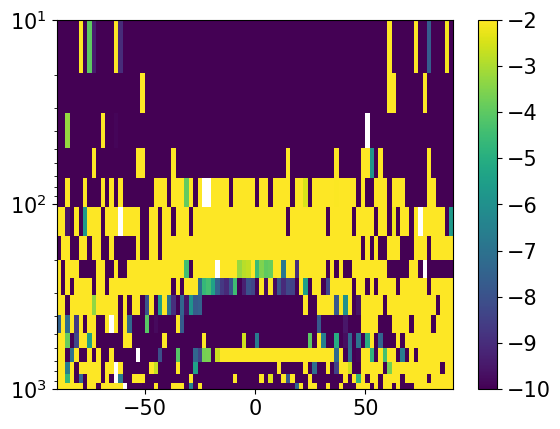

In [97]:
fig, ax = plt.subplots()
plt.pcolormesh(lapse_ini.lat, lapse_ini.plev, lapse_ini.values, vmin = -10, vmax = -2)
ax.set_yscale('log')
ax.set_ylim(1000., 10.)
#ax.set_yscale('linear')
plt.colorbar()

In [80]:
ta_ok = experiment.ds.ta.mean(['time', 'lon']).compute()

In [84]:
ta_ok.sel(plev = 300.) - ta_ok.sel(plev = 200.)

<xarray.DataArray 'ta' (lat: 90)> Size: 360B
array([ 7.9306793,  7.939026 ,  7.9697876,  8.034973 ,  8.146347 ,
        8.293945 ,  8.470398 ,  8.653778 ,  8.821945 ,  8.955383 ,
        9.048523 ,  9.126175 ,  9.247055 ,  9.48056  ,  9.876892 ,
       10.452072 , 11.18251  , 12.016922 , 12.889923 , 13.73703  ,
       14.513947 , 15.188263 , 15.748154 , 16.196579 , 16.546326 ,
       16.814392 , 17.030441 , 17.245346 , 17.523972 , 17.911667 ,
       18.411896 , 18.97844  , 19.54216  , 20.046661 , 20.46762  ,
       20.807571 , 21.077438 , 21.279694 , 21.422516 , 21.508804 ,
       21.55368  , 21.569534 , 21.57602  , 21.579407 , 21.579025 ,
       21.569962 , 21.54683  , 21.518875 , 21.487747 , 21.445572 ,
       21.3721   , 21.248932 , 21.07341  , 20.850906 , 20.591034 ,
       20.306335 , 20.014221 , 19.719284 , 19.416824 , 19.084381 ,
       18.723679 , 18.352127 , 17.96341  , 17.54094  , 17.084167 ,
       16.61908  , 16.154602 , 15.6779175, 15.189087 , 14.69223  ,
       14.20137  , 13.72702  , 13.278198 , 12.863022 , 12.482788 ,
       12.134979 , 11.81517  , 11.505966 , 11.189972 , 10.855774 ,
       10.49913  , 10.1293335,  9.76329  ,  9.42424  ,  9.1185   ,
        8.84845  ,  8.625412 ,  8.448563 ,  8.327011 ,  8.270721 ],
      dtype=float32)
Coordinates:
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
    height   float64 8B 2.0
Attributes:
    regrid_method:  bilinear

In [1]:
lapse_ini.plev

NameError: name 'lapse_ini' is not defined

In [64]:
lapse_ok_ini.plev

<xarray.DataArray 'plev' (plev: 23)> Size: 92B
array([1000. ,  975. ,  950. ,  925. ,  900. ,  875. ,  850. ,  825. ,  800. ,
        775. ,  725. ,  625. ,  525. ,  425. ,  325. ,  237.5,  187.5,  137.5,
         85. ,   40. ,   15. ,    6. ,    2.5], dtype=float32)
Coordinates:
  * plev     (plev) float32 92B 1e+03 975.0 950.0 925.0 ... 40.0 15.0 6.0 2.5

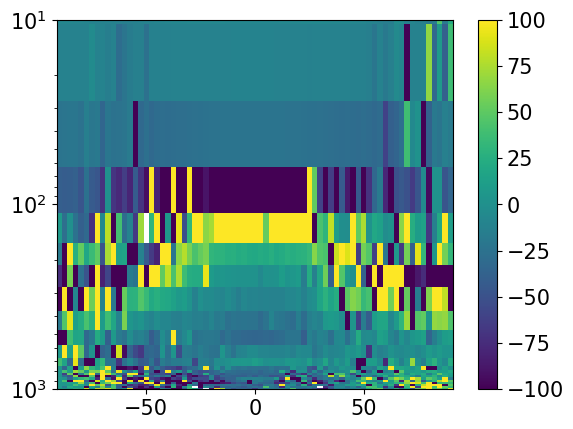

In [75]:
fig, ax = plt.subplots()
plt.pcolormesh(lapse_ok_ini.lat, lapse_ok_ini.plev, lapse_ok_ini.values, vmin = -100, vmax = 100)
ax.set_yscale('log')
ax.set_ylim(1000., 10.)
#ax.set_yscale('linear')
plt.colorbar()

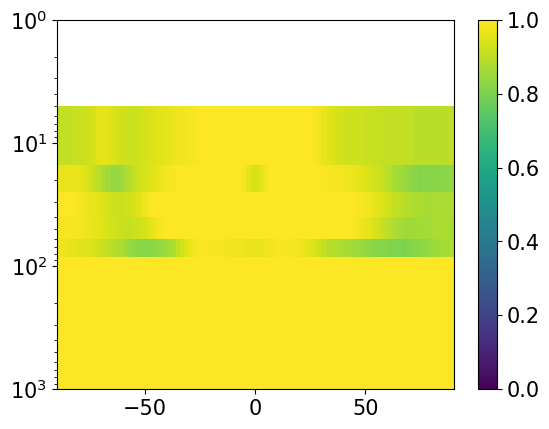

: 

In [ ]:
fig, ax = plt.subplots()
plt.pcolormesh(cond_ini.lat, cond_ini.plev, cond_ini.values, vmin = 0, vmax = 1)
ax.set_yscale('log')
ax.set_ylim(1000., 1.)
#ax.set_yscale('linear')
plt.colorbar()

(1000.0, 10.0)

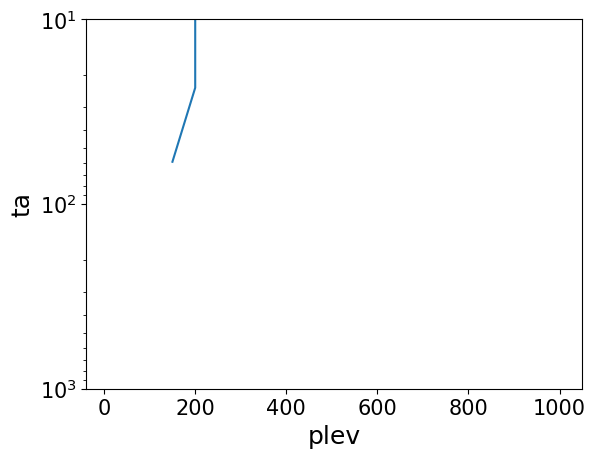

In [58]:
fig, ax = plt.subplots()
#plt.pcolormesh(lapse_ini.lat, lapse_ini.plev, lapse_ini.values, vmin = -100, vmax = 100)
lapse_ini.sel(lat = slice(-30, 30)).mean('lat').plot()
ax.set_yscale('log')
ax.set_ylim(1000., 10.)
#ax.set_yscale('linear')

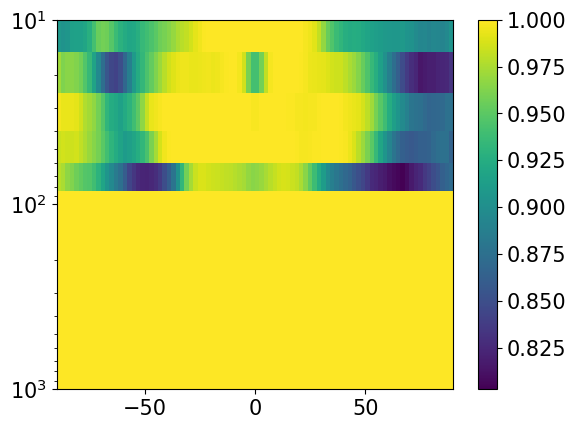

In [66]:
fig, ax = plt.subplots()
plt.pcolormesh(cond_ini.lat, cond_ini.plev, cond_ini.values)#, vmin = -10, vmax = 10)
ax.set_yscale('log')
ax.set_ylim(1000., 10.)
#ax.set_yscale('linear')
plt.colorbar()

## Spectral calc
This runs in 43 min with 4x4 workers (32 Gb each group)

After update of WV kernels, WV computes in ~13 min with 4x4 workers (64 Gb each group)

In [28]:
kernel.wv_method

'hybrid'

In [6]:
cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_hybrid/'
anoms = sfc.calc_anoms(experiment, control, kernel, cart_out, use_strat_mask=False, save_pattern=False, force_recompute=False)

NameError: name 'experiment' is not defined

## Compare different WV kernels

In [39]:
cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_log/'
anoms_log = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_lin/'
anoms_lin = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_hybrid/'
anoms_hybrid = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

In [40]:
cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_2/'
anoms_old = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

In [41]:
anoms_huang = sfc.open_dRt(cart_out + '../fb_HUANG_ok/', names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

In [7]:
%matplotlib inline

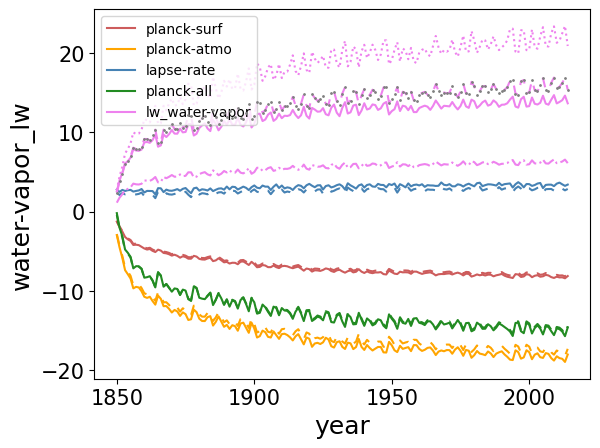

In [ ]:
fig = plt.figure()
tip = 'clr'
fb_list = ['planck-surf', 'planck-atmo', 'lapse-rate', 'planck-all', 'lw_water-vapor']
colors = ['indianred', 'orange', 'steelblue', 'forestgreen', 'violet']
anoms_old[(tip, 'planck-all')] = anoms_old[(tip, 'planck-atmo')] + anoms_old[(tip, 'lapse-rate')]
anoms_huang[(tip, 'planck-all')] = anoms_huang[(tip, 'planck-atmo')] + anoms_huang[(tip, 'lapse-rate')]

for cos, col in zip(fb_list, colors):
    anoms_huang[(tip, cos)].plot(color = col, label = cos)
    (anoms_old[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot(color = col, ls = '--')
    if 'water' in cos:
        (anoms_lin[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot(color = col, ls = ':')
        (anoms_log[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot(color = col, ls = '-.')
        (anoms_hybrid[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot.scatter(color = 'grey', marker = 'o', s = 1, zorder = 10)
plt.legend()

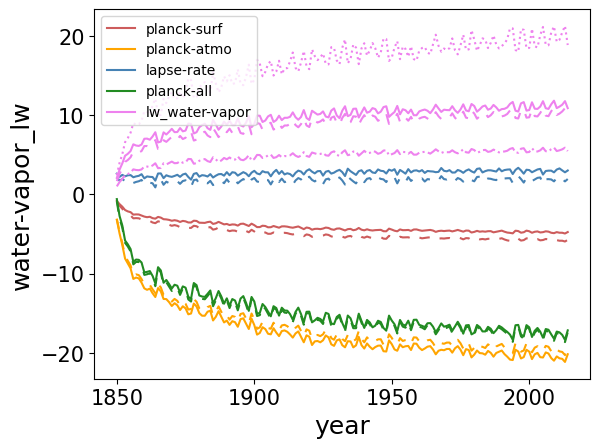

In [ ]:
fig = plt.figure()
tip = 'cld'
fb_list = ['planck-surf', 'planck-atmo', 'lapse-rate', 'planck-all', 'lw_water-vapor']
colors = ['indianred', 'orange', 'steelblue', 'forestgreen', 'violet']
anoms_old[(tip, 'planck-all')] = anoms_old[(tip, 'planck-atmo')] + anoms_old[(tip, 'lapse-rate')]
anoms_huang[(tip, 'planck-all')] = anoms_huang[(tip, 'planck-atmo')] + anoms_huang[(tip, 'lapse-rate')]

for cos, col in zip(fb_list, colors):
    anoms_huang[(tip, cos)].plot(color = col, label = cos)
    (anoms_old[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot(color = col, ls = '--')
    if 'water' in cos:
        (anoms_lin[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot(color = col, ls = ':')
        (anoms_log[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot(color = col, ls = '-.')
        (anoms_hybrid[(tip, cos)].integrate('freq').groupby('time.year').mean()).plot.scatter(color = 'grey', marker = 'o')
plt.legend()

In [11]:
fb_list_1 = ['planck-surf', 'planck-all', 'lw_water-vapor']
anoms_old[('clr', 'all')] = 0.*anoms_old[('clr', fb_list[0])]
for cos in fb_list_1:
    anoms_old[('clr', 'all')] += anoms_old[('clr', cos)]

KeyError: ('clr', 'all')

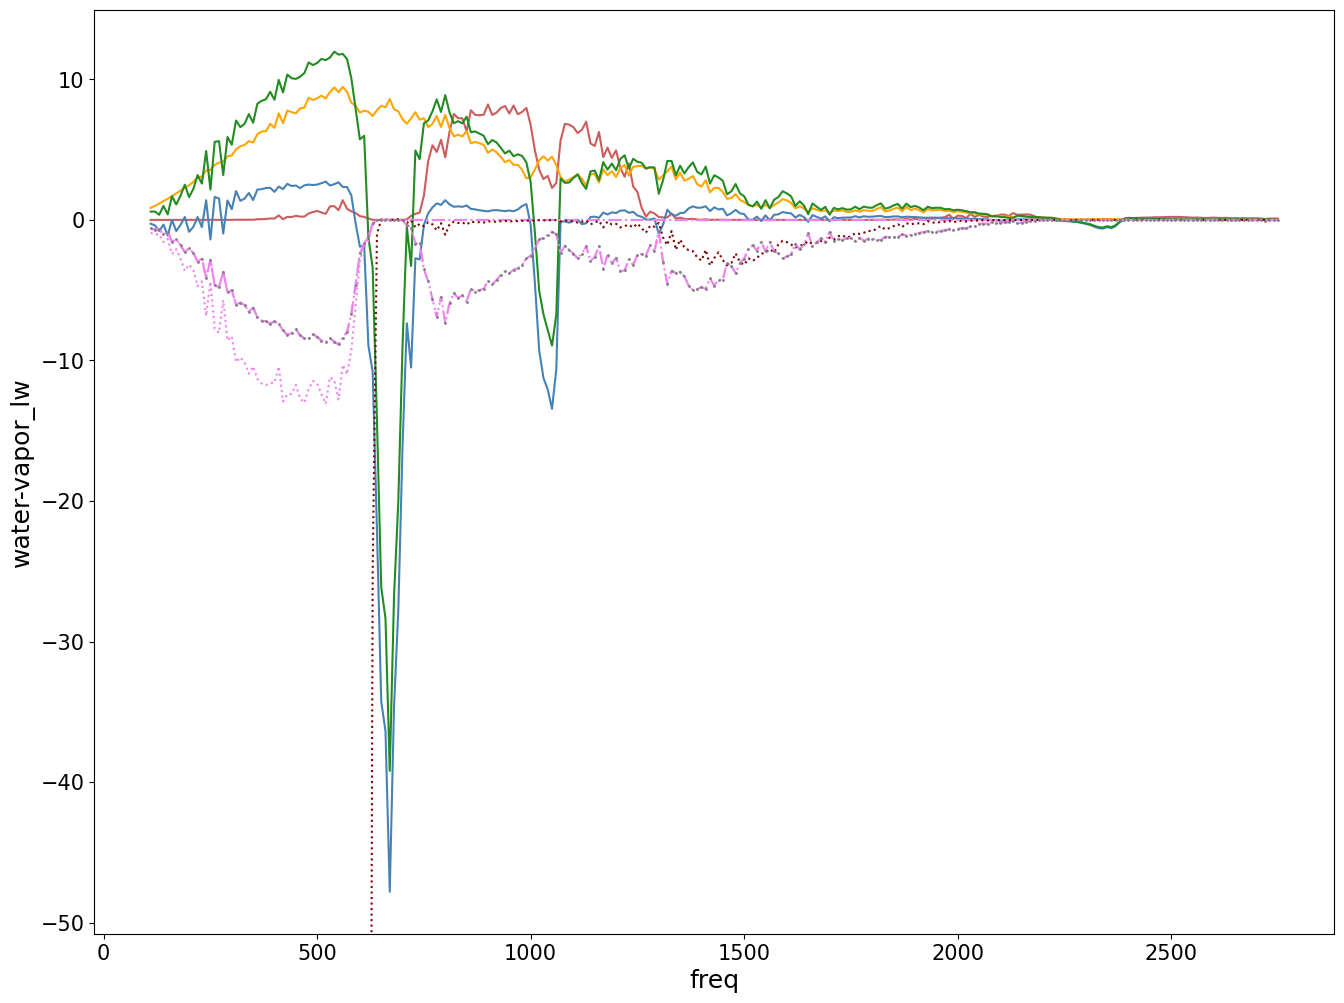

In [46]:
tip = 'clr'

plt.figure(figsize = (16,12))
for cos, col in zip(fb_list, colors + ['violet']):
    if 'water' in cos:
        anoms_lin[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = col, ls = ':', label = 'wv lin')
        anoms_log[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = col, ls = '-.', label = 'wv log')
        yli = plt.gca().get_ylim()
        (100*(anoms_log[(tip, cos)].isel(time = slice(0, 120)).mean('time'))).plot(color = 'maroon', ls = ':', label = 'wv log 2')
        plt.gca().set_ylim(yli)
        anoms_old[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = 'violet', label = 'wv hybrid', ls = '--')
        anoms_hybrid[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot.scatter(color = 'grey', marker = 'o', s = 1, zorder = 10)
    else:
        anoms_old[(tip, cos)].isel(time = slice(0, 120)).mean('time').plot(color = col, label = cos)

anoms_old[('clr', 'all')].isel(time = slice(0, 120)).mean('time').plot(color = 'black', label = 'all')
plt.ylabel('dR (W/m2/cm-1)')

plt.legend()